In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

import plotly.io as pio
pio.renderers.default = "notebook"
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor
import warnings
warnings. filterwarnings('ignore')

In [2]:
!pip install plotly -q
!pip install kaleido -q
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_dark"
pio.renderers.default = "colab"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.4 MB/s eta 0:00:00


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "survey_results_public.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ebrahimelgazar/stack-overflow-2022-developer-survey",
  file_path,
)

100%|██████████| 11.7M/11.7M [00:00<00:00, 26.3MB/s]

Extracting zip of survey_results_public.csv...


In [4]:
df.columns

Index(['ResponseId', 'MainBranch', 'Employment', 'RemoteWork',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType',
       'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'Country', 'Currency',
       'CompTotal', 'CompFreq', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith',
       'NEWCollabToolsWantToWorkWith', 'OpSysProfessional use',
       'OpSysPersonal use', 'VersionControlSystem', 'VCInteraction',
       'VCHostingPersonal use', 'VCHostingProfessional use',
       'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',
       'OfficeStackSyncHaveWork

In [5]:
df.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Difficult,NaN
2,3,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Friend or family member...,Technical documentation;Blogs;Programming Game...,NaN,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,40205.0
3,4,I am a developer by profession,"Employed, full-time",Fully remote,I don’t code outside of work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,215232.0
4,5,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;O...,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

# Visualization

In [7]:
def plot_line_chart(df, column, line=""):
    if line == '':
        line = df[column].value_counts().keys()[0:20]
    data = df[column].value_counts()[0:20]
    fig=px.line(x=line,y=data)
    fig.show()

def plot_bar_chart(df, column, line=""):
    if line == '':
        line = df[column].value_counts().keys()[0:20]
    data = df[column].value_counts()[0:20]
    fig=px.bar(x=line,y=data)
    fig.show()

def plot_pie_chart(df, column, line = ''):
    if line == '':
        line = df[column].value_counts().keys()[0:20]
    data = df[column].value_counts()[0:20]
    fig=px.pie(names=line,values=data)
    fig.show()

In [8]:
plot_bar_chart(df,"Country")
plot_line_chart(df,"Country")

In [9]:
line = df['MainBranch'].value_counts().index.tolist()

plot_line_chart(df, 'MainBranch', line)
plot_bar_chart(df, 'MainBranch', line)
plot_pie_chart(df, 'MainBranch', line)

In [10]:
plot_bar_chart(df,"Employment")
plot_line_chart(df,"Employment")
plot_pie_chart(df,"Employment")

In [11]:
plot_bar_chart(df,"EdLevel")
plot_pie_chart(df,"EdLevel")

In [12]:
df.columns

Index(['ResponseId', 'MainBranch', 'Employment', 'RemoteWork',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType',
       'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'Country', 'Currency',
       'CompTotal', 'CompFreq', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith',
       'NEWCollabToolsWantToWorkWith', 'OpSysProfessional use',
       'OpSysPersonal use', 'VersionControlSystem', 'VCInteraction',
       'VCHostingPersonal use', 'VCHostingProfessional use',
       'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',
       'OfficeStackSyncHaveWork

In [13]:
plot_bar_chart(df,"YearsCodePro")
plot_pie_chart(df,"YearsCodePro")

In [14]:
df[["DevType"]]

,DevType
0,NaN
1,NaN
2,Data scientist or machine learning specialist;...
3,"Developer, full-stack"
4,"Developer, front-end;Developer, full-stack;Dev..."
...,...
73263,"Developer, back-end"
73264,Data scientist or machine learning specialist
73265,"Developer, full-stack;Developer, desktop or en..."
73266,"Developer, front-end;Developer, desktop or ent..."


In [15]:
df_DevType = df['DevType'].dropna().str.split(';', expand=True).stack().reset_index(drop=True)
df_DevType = pd.DataFrame(df_DevType, columns=['DevType'])

print(df_DevType['DevType'].value_counts().head(10))

DevType
Developer, full-stack                            28701
Developer, back-end                              26595
Developer, front-end                             15915
Developer, desktop or enterprise applications     9546
Developer, mobile                                 7634
DevOps specialist                                 6170
Student                                           5595
Cloud infrastructure engineer                     5283
Database administrator                            4934
System administrator                              4908
Name: count, dtype: int64


In [16]:
df_expanded = df.copy()
df_expanded = df_expanded.assign(DevType=df_expanded['DevType'].str.split(';')).explode('DevType')
dev_salary = df_expanded.groupby('DevType')['ConvertedCompYearly'].mean().sort_values(ascending=False)

fig = px.bar(dev_salary, title="Average Salary by Developer Type")
fig.show()

In [17]:
plot_bar_chart(df_DevType,"DevType")
plot_pie_chart(df_DevType,"DevType")

# Feature Selection

In [18]:
df = df[["Country", "EdLevel", "YearsCodePro","Employment", "ConvertedCompYearly"]]
df = df.rename({"ConvertedCompYearly": "Salary"}, axis=1)
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
0,NaN,NaN,NaN,NaN,NaN
1,Canada,NaN,NaN,"Employed, full-time",NaN
2,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0
3,Israel,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0
4,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",3,"Employed, full-time",NaN


In [19]:
df = df[df["Salary"].notnull()]
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
2,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0
3,Israel,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0
8,Netherlands,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6,"Employed, full-time",49056.0
10,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,"Employed, full-time",60307.0
11,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10,"Employed, full-time;Independent contractor, fr...",194400.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38071 entries, 2 to 73121
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       38071 non-null  object 
 1   EdLevel       38054 non-null  object 
 2   YearsCodePro  37935 non-null  object 
 3   Employment    38067 non-null  object 
 4   Salary        38071 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.7+ MB


In [21]:
df = df.dropna()
df.isnull().sum()

,0
Country,0
EdLevel,0
YearsCodePro,0
Employment,0
Salary,0


In [22]:
df.columns

Index(['Country', 'EdLevel', 'YearsCodePro', 'Employment', 'Salary'], dtype='object')

In [23]:
df["Country"].value_counts()

,count
Country,
United States of America,8684
Germany,2901
United Kingdom of Great Britain and Northern Ireland,2649
India,2154
Canada,1478
...,...
Haiti,1
Palau,1
Monaco,1


In [24]:
df["Employment"].value_counts()

,count
Employment,
"Employed, full-time",31382
"Independent contractor, freelancer, or self-employed",2739
"Employed, full-time;Independent contractor, freelancer, or self-employed",2633
"Employed, part-time",632
"Independent contractor, freelancer, or self-employed;Employed, part-time",207
"Employed, full-time;Employed, part-time",151
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time",118
I prefer not to say,27
Retired,18


In [25]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')

In [26]:
print_unique_col_values(df)

Country: ['United Kingdom of Great Britain and Northern Ireland' 'Israel'
 'Netherlands' 'United States of America' 'Czech Republic' 'Austria'
 'Italy' 'Canada' 'Germany' 'Ireland' 'Poland' 'Madagascar' 'Norway'
 'Taiwan' 'France' 'Brazil' 'Uruguay' 'Sweden' 'Spain' 'Turkey' 'Romania'
 'Singapore' 'India' 'Belgium' 'Bulgaria' 'Greece' 'Portugal'
 'Russian Federation' 'Saudi Arabia' 'Mexico' 'Kenya' 'Switzerland'
 'Latvia' 'South Africa' 'Thailand' 'China' 'Montenegro' 'Finland'
 'Slovakia' 'Japan' 'Denmark' 'Australia' 'Viet Nam' 'Argentina' 'Hungary'
 'Tunisia' 'Bangladesh' 'Ukraine' 'Maldives' 'Hong Kong (S.A.R.)' 'Egypt'
 'Serbia' 'Pakistan' 'Nepal' 'Croatia' 'Indonesia'
 'Bosnia and Herzegovina' 'Armenia' 'Lithuania'
 'Iran, Islamic Republic of...' 'Belarus' 'Costa Rica' 'Mauritius'
 'Estonia' 'Kazakhstan' 'Morocco' 'Philippines' 'Chile' 'New Zealand'
 'Slovenia' 'Ecuador' 'Cyprus' 'Peru' 'Colombia' 'Afghanistan' 'Nicaragua'
 'Andorra' 'Republic of Korea' 'Lebanon' 'South Korea' 'M

In [27]:
df = df[df["Employment"] == "Employed, full-time"]
df = df.drop("Employment", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31382 entries, 2 to 73121
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       31382 non-null  object 
 1   EdLevel       31382 non-null  object 
 2   YearsCodePro  31382 non-null  object 
 3   Salary        31382 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [28]:
df['Country'].value_counts()

,count
Country,
United States of America,7858
Germany,2382
United Kingdom of Great Britain and Northern Ireland,2341
India,1869
Canada,1249
...,...
Guinea,1
Yemen,1
Monaco,1


In [29]:
def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories.values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = 'Other'
    return categorical_map

In [30]:
country_map = shorten_categories(df.Country.value_counts(), 199)
df['Country'] = df['Country'].map(country_map)
df.Country.value_counts()

,count
Country,
United States of America,7858
Other,4696
Germany,2382
United Kingdom of Great Britain and Northern Ireland,2341
India,1869
Canada,1249
France,1126
Brazil,1014
Spain,858


In [31]:
fig = px.box(df, x="Country", y="Salary")
fig.show()

In [32]:
df = df[df["Salary"] <= 300000]
df = df[df["Salary"] >= 10000]
df = df[df['Country'] != 'Other']

In [33]:
fig = px.box(df, x="Country", y="Salary")
fig.show()

In [34]:
df["YearsCodePro"].unique()

array(['5', '17', '6', '2', '4', '10', '22', '20', '9', '14', '21', '15',
       '3', '25', '7', '8', '12', '19', '24', '1', '11', '23',
       'Less than 1 year', '18', '37', '46', '13', '32', '27', '28', '16',
       '31', '30', '34', '35', '26', '42', '38', '36', '40', '41', '29',
       '33', '39', '48', '45', '44', '43', 'More than 50 years', '47',
       '49', '50'], dtype=object)

In [35]:
def clean_experience(x):
    if x ==  'More than 50 years':
        return 50
    if x == 'Less than 1 year':
        return 0.5
    return float(x)

df['YearsCodePro'] = df['YearsCodePro'].apply(clean_experience)

In [36]:
df["EdLevel"].unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Something else', 'Associate degree (A.A., A.S., etc.)',
       'Some college/university study without earning a degree',
       'Professional degree (JD, MD, etc.)',
       'Other doctoral degree (Ph.D., Ed.D., etc.)',
       'Primary/elementary school'], dtype=object)

In [37]:
def clean_education(x):
    if 'Bachelor’s degree' in x:
        return 'Bachelor’s degree'
    if 'Master’s degree' in x:
        return 'Master’s degree'
    if 'Professional degree' in x or 'Other doctoral' in x:
        return 'Post grad'
    return 'Less than a Bachelors'

df['EdLevel'] = df['EdLevel'].apply(clean_education)

In [38]:
df["EdLevel"].unique()

array(['Master’s degree', 'Bachelor’s degree', 'Less than a Bachelors',
       'Post grad'], dtype=object)

In [39]:
df.sample(5)

,Country,EdLevel,YearsCodePro,Salary
20362,Germany,Less than a Bachelors,4.0,51192.0
45237,United States of America,Bachelor’s degree,10.0,108000.0
50102,United States of America,Master’s degree,6.0,115000.0
68776,Belgium,Bachelor’s degree,3.0,42228.0
6959,Italy,Bachelor’s degree,8.0,49056.0


# Model Training

In [40]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [41]:
X

,Country,EdLevel,YearsCodePro
2,United Kingdom of Great Britain and Northern I...,Master’s degree,5.0
3,Israel,Bachelor’s degree,17.0
8,Netherlands,Master’s degree,6.0
10,United Kingdom of Great Britain and Northern I...,Bachelor’s degree,2.0
12,United States of America,Bachelor’s degree,5.0
...,...,...,...
73113,United States of America,Master’s degree,5.0
73116,United States of America,Bachelor’s degree,16.0
73119,United States of America,Bachelor’s degree,1.0
73120,Spain,Bachelor’s degree,2.0


In [42]:
X = df.iloc[:,:3]
y = df["Salary"]

In [52]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

edu_categories = ['Less than a Bachelors', 'Bachelor’s degree', 'Master’s degree', 'Post grad']

transformer = ColumnTransformer([
    ('num', StandardScaler(), ['YearsCodePro']),
    ('country', OneHotEncoder(handle_unknown='ignore'), ['Country']),
    ('education', OrdinalEncoder(categories=[edu_categories]), ['EdLevel'])
])

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.10, random_state=85)

In [53]:
mean_salary = df["Salary"].mean()
print("${:,.02f}".format(mean_salary))

$89,475.22


In [54]:
mlpipe1 = Pipeline([('Transformer', transformer), ('lr', LinearRegression())])
mlpipe1.fit(X_train, y_train)

Pipeline(steps=[('Transformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['YearsCodePro']),
                                                 ('country',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country']),
                                                 ('education',
                                                  OrdinalEncoder(categories=[['Less '
                                                                              'than '
                                                                              'a '
                                                                              'Bachelors',
                                                                              'Bachelor’s '
                                                                              'degree',
                                                                              'Master’s '
                                                                              'degree',
                                                                              'Post '
                                                                              'grad']]),
                                                  ['EdLevel'])])),
                ('lr', LinearRegression())])

In [55]:
y_had = mlpipe1.predict(X_test)
y_had

array([ 41457.03660583,  25079.32661308,  38089.45873702, ...,
        77474.64303955, 124355.84807892, 134642.922752  ])

In [56]:
score = mlpipe1.score(X_test, y_test)
print(f"R-squared Score: {score * 100:.2f}%")
print(f"This model explains {score * 100:.2f}% of the variance in salary data.")

R-squared Score: 48.90%
This model explains 48.90% of the variance in salary data.


In [57]:
errors = np.sqrt(mean_squared_error(y_test, y_had))
print("${:,.02f}".format(errors))

$41,652.82


In [58]:
mlpipe2 = Pipeline([('Transformer', transformer), ('dt', DecisionTreeRegressor())])
mlpipe2.fit(X_train, y_train)

Pipeline(steps=[('Transformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['YearsCodePro']),
                                                 ('country',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country']),
                                                 ('education',
                                                  OrdinalEncoder(categories=[['Less '
                                                                              'than '
                                                                              'a '
                                                                              'Bachelors',
                                                                              'Bachelor’s '
                                                                              'degree',
                                                                              'Master’s '
                                                                              'degree',
                                                                              'Post '
                                                                              'grad']]),
                                                  ['EdLevel'])])),
                ('dt', DecisionTreeRegressor())])

In [59]:
y_had = mlpipe2.predict(X_test)
y_had

array([ 41574.61764706,  38116.72727273,  28159.2       , ...,
        99447.55555556, 102430.59016393, 135962.48178138])

In [60]:
error1 = np.sqrt(mean_squared_error(y_test, y_had))
print("${:,.02f}".format(error1))

$42,395.55


In [61]:
mlpipe3 = Pipeline([('Transformer', transformer), ('xgb',XGBRegressor())])
mlpipe3.fit(X_train, y_train)

Pipeline(steps=[('Transformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['YearsCodePro']),
                                                 ('country',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country']),
                                                 ('education',
                                                  OrdinalEncoder(categories=[['Less '
                                                                              'than '
                                                                              'a '
                                                                              'Bachelors',
                                                                              'Bachelor’s '
                                                                              'degree',
                                                                              'Master’s '
                                                                              'degree',
                                                                              'Post '
                                                                              'grad']]),
                                                  ['EdLevel'])])),
                ('xgb',
                 XGBRegressor(base_score=None, booste...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [62]:
y_had = mlpipe3.predict(X_test)
y_had

array([ 40252.855,  32744.996,  30365.545, ...,  95128.8  , 104162.82 ,
       135761.92 ], dtype=float32)

In [63]:
error = np.sqrt(mean_squared_error(y_test, y_had))
print("${:,.02f}".format(error))

$41,015.24


## Model Refinement & Outlier Treatment

In [64]:
df = df[(df['Salary'] >= 5000) & (df['Salary'] <= 250000)]

In [65]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=85)
mlpipe3.fit(X_train, y_train)

y_had3 = mlpipe3.predict(X_test)
new_error = np.sqrt(mean_squared_error(y_test, y_had3))
new_mean = df["Salary"].mean()

print(f"New Mean Salary: ${new_mean:,.02f}")
print(f"New Random Forest Error: ${new_error:,.02f}")
print(f"Error Percentage: {(new_error/new_mean)*100:.2f}%")

New Mean Salary: $86,378.25
New Random Forest Error: $35,195.21
Error Percentage: 40.75%


In [66]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

edu_categories = ['Less than a Bachelors', 'Bachelor’s degree', 'Master’s degree', 'Post grad']
transformer = ColumnTransformer([
    ('country', OneHotEncoder(handle_unknown='ignore'), ['Country']),
    ('education', OrdinalEncoder(categories=[edu_categories]), ['EdLevel'])

], remainder='passthrough')

mlpipe_optimized = Pipeline([
    ('Transformer', transformer),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=85))
])
X = df[['Country', 'EdLevel', 'YearsCodePro']]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=85)
mlpipe_optimized.fit(X_train, y_train)

Pipeline(steps=[('Transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('country',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country']),
                                                 ('education',
                                                  OrdinalEncoder(categories=[['Less '
                                                                              'than '
                                                                              'a '
                                                                              'Bachelors',
                                                                              'Bachelor’s '
                                                                              'degree',
                                                                              'Master’s '
                                                                              'degree',
                                                                              'Post '
                                                                              'grad']]),
                                                  ['EdLevel'])])),
                ('rf',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=5,
                                       n_estimators=300, random_state=85))])

In [67]:
y_pred = mlpipe_optimized.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mean_sal = y_test.mean()

print(f"Final RMSE: ${final_rmse:,.02f}")
print(f"Average Salary: ${mean_sal:,.02f}")
print(f"Error Percentage: {(final_rmse/mean_sal)*100:.2f}%")

Final RMSE: $35,119.86
Average Salary: $86,904.77
Error Percentage: 40.41%


In [68]:
# --- Section: Model Training with XGBoost ---
# Initializing the XGBoost Regressor within the Pipeline
mlpipe_xgb = Pipeline([
    ('Transformer', transformer),
    ('xgb', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=85))
])

# Training the model on the refined dataset
mlpipe_xgb.fit(X_train, y_train)

# Model Evaluation
y_pred_final = mlpipe_xgb.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"Final RMSE (XGBoost): ${final_rmse:,.02f}")
print(f"Error Percentage: {(final_rmse / y_test.mean()) * 100:.2f}%")

Final RMSE (XGBoost): $34,858.87
Error Percentage: 40.11%


In [70]:
y_pred_final = mlpipe_xgb.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mean = y_test.mean()
error_percent = (final_rmse / final_mean) * 100

print(f"Final RMSE (Error): ${final_rmse:,.02f}")
print(f"Average Salary:     ${final_mean:,.02f}")
print(f"Error Percentage:   {error_percent:.2f}%")

Final RMSE (Error): $34,858.87
Average Salary:     $86,904.77
Error Percentage:   40.11%


In [71]:
# --- Section: Salary Prediction Function ---
def predict_salary(country, education, experience):
    X_new = pd.DataFrame([[country, education, experience]],
                         columns=['Country', 'EdLevel', 'YearsCodePro'])

    prediction = mlpipe_xgb.predict(X_new)[0]

    print(f"--- AI Salary Prediction Result ---")
    print(f"Country: {country}")
    print(f"Education: {education}")
    print(f"Experience: {experience} years")
    print(f"Estimated Annual Salary: ${prediction:,.02f}")
    return prediction

# Example Prediction
salary_guess = predict_salary('United States of America', 'Master’s degree', 5)

--- AI Salary Prediction Result ---
Country: United States of America
Education: Master’s degree
Experience: 5 years
Estimated Annual Salary: $144,168.55


In [72]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Hyperparameter Grid for XGBoost
param_grid = {
    'xgb__n_estimators': [100, 300],
    'xgb__max_depth': [6, 10],
}

# Running GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(mlpipe_xgb, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

# Performing Cross-Validation to check stability
cv_scores = cross_val_score(best_model, X, y, cv=3, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print(f"--- Model Stability Report ---")
print(f"Average RMSE: ${cv_rmse.mean():,.02f}")
print(f"Stability Score: {100 - (cv_rmse.std()/cv_rmse.mean()*100):.2f}%")

Best Parameters Found: {'xgb__max_depth': 6, 'xgb__n_estimators': 100}
--- Model Stability Report ---
Average RMSE: $34,094.51
Stability Score: 99.36%


In [73]:
# Model Performance Evaluation
final_score = mlpipe_xgb.score(X_test, y_test)
y_pred = mlpipe_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Final Model Report ---")
print(f"R-squared Score: {final_score * 100:.2f}%")
print(f"RMSE: ${rmse:,.02f}")

--- Final Model Report ---
R-squared Score: 55.92%
RMSE: $34,858.87


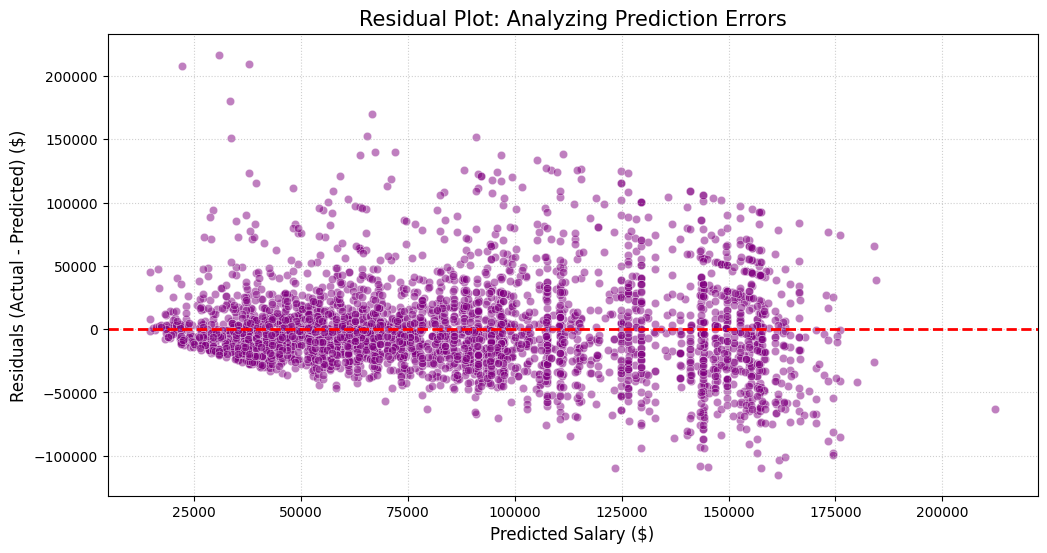

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred_final
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred_final, y=residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot: Analyzing Prediction Errors', fontsize=15)
plt.xlabel('Predicted Salary ($)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted) ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Predict a new data

In [75]:
X_new = np.array([["Iran , Islamic Republic of ...", 'Masters degree', 5]])
X_new

array([['Iran , Islamic Republic of ...', 'Masters degree', '5']],
      dtype='<U30')

In [77]:
df.columns

Index(['Country', 'EdLevel', 'YearsCodePro', 'Salary'], dtype='object')

In [78]:
columns = ['Country', 'EdLevel', 'YearsCodePro',]
X_new_df = pd.DataFrame(X_new, columns=columns)
X_new_df

,Country,EdLevel,YearsCodePro
0,"Iran , Islamic Republic of ...",Masters degree,5


In [80]:
X_new_df['EdLevel'] = X_new_df['EdLevel'].replace('Masters degree', 'Master’s degree')
X_new_df['Country'] = X_new_df['Country'].replace('Iran , Islamic Republic of ...', 'Iran, Islamic Republic of...')

prediction = mlpipe_xgb.predict(X_new_df)
print(f"Predicted Salary for the input: ${prediction[0]:,.02f}")

Predicted Salary for the input: $60,295.71


In [81]:
import joblib

In [82]:
# --- Section: Model Deployment ---
# Saving the trained XGBoost Pipeline
import joblib
joblib.dump(mlpipe_xgb, 'xgbpipe.joblib')

['xgbpipe.joblib']